# TFM: (NOMBRE QUE LE QUERAS DAR AL PROYECTO - Sistema de Valoración Automatizada (AVM)
## Notebook 1: Ingestión de Datos, Arquitectura y Monitorización

**Autora:** Jorge Aldavero Romero

### 1. Estrategia de Ingeniería de Datos
Para este proyecto, no me conformo con datasets estáticos. He diseñado una arquitectura de ingestión capaz de capturar el mercado inmobiliario en tiempo real.

Mi objetivo es obtener **10.000 activos únicos** de Madrid, enriqueciendo los datos tradicionales (precio, metros) con variables de alto valor que suelen ignorarse:
* **Multimedia:** Carruseles de imágenes para aplicar Visión Artificial.
* **Cualitativos:** Certificación energética, presencia de ascensor y estado de conservación.

Para garantizar la escalabilidad, he implementado una **Base de Datos Relacional (SQL)** que actúa como mi "Data Lake", asegurando que ningún dato se pierda durante el proceso de extracción masiva.

In [12]:
# ==============================================================================
# 1. CONFIGURACIÓN DEL ENTORNO Y LIBRERÍAS
# ==============================================================================

# Importamos las herramientas de ingeniería de datos
import sqlite3                    # Base de datos SQL (Persistencia)
import pandas as pd               # Manipulación de DataFrames
import numpy as np                # Cálculos matemáticos
import requests                   # Peticiones Web
import time, random               # Gestión de tiempos y aleatoriedad
import matplotlib.pyplot as plt   # Visualización gráfica
import seaborn as sns             # Estilos de gráficos pro
from IPython.display import clear_output, HTML, display # Para el Dashboard en vivo
from datetime import datetime     # Marca temporal
import os                         # Gestión de archivos

# Configuración visual para que los gráficos tengan estilo académico/pro
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [12, 6]

print("✅ Entorno de Ingeniería de Datos configurado correctamente.")
print("   - Motor SQL: Listo")
print("   - Sistema de Visualización: Listo")

✅ Entorno de Ingeniería de Datos configurado correctamente.
   - Motor SQL: Listo
   - Sistema de Visualización: Listo


### 2. Arquitectura de Datos: El "Schema" SQL

He diseñado una estructura de base de datos relacional robusta. A diferencia de un CSV plano, esta tabla SQL garantiza la integridad de los tipos de datos.

He incluido campos específicos para el enriquecimiento:
* `banos`: Variable crítica que faltaba en versiones anteriores.
* `urls_fotos`: Un campo de texto que almacenará arrays de URLs, preparando el terreno para el módulo de Deep Learning.

In [13]:
# ==============================================================================
# 2. DEFINICIÓN DE LA ARQUITECTURA (DATABASE SCHEMA)
# ==============================================================================

DB_NAME = 'tasia_db_def1.db'

# Medida de seguridad: Si existe una base de datos corrupta previa, la eliminamos
if os.path.exists(DB_NAME):
    os.remove(DB_NAME)
    print(f"🗑️ Limpieza: Archivo antiguo '{DB_NAME}' eliminado para evitar conflictos.")

def inicializar_arquitectura():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    # Creamos la tabla con las 15 COLUMNAS EXACTAS necesarias
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS viviendas (
            id_referencia TEXT PRIMARY KEY,   -- 1. ID Único
            titulo TEXT,                      -- 2. Título
            precio REAL,                      -- 3. Target (Y)
            barrio TEXT,                      -- 4. Ubicación fina
            distrito TEXT,                    -- 5. Ubicación macro
            superficie REAL,                  -- 6. M2
            habitaciones INTEGER,             -- 7. Num Habs
            banos INTEGER,                    -- 8. Num Baños (¡IMPORTANTE!)
            planta TEXT,                      -- 9. Altura
            tiene_ascensor INTEGER,           -- 10. Variable de valor (1/0)
            tiene_terraza INTEGER,            -- 11. Variable de valor (1/0)
            estado TEXT,                      -- 12. Conservación
            certificado_energetico TEXT,      -- 13. Eficiencia
            urls_fotos TEXT,                  -- 14. Multimedia
            fecha_captura DATETIME            -- 15. Auditoría
        )
    ''')
    conn.commit()
    conn.close()
    print(f"✅ Arquitectura SQL inicializada: {DB_NAME}")
    print("   - Tabla 'viviendas' creada con 15 columnas.")

inicializar_arquitectura()

🗑️ Limpieza: Archivo antiguo 'tasia_db_def1.db' eliminado para evitar conflictos.
✅ Arquitectura SQL inicializada: tasia_db_def1.db
   - Tabla 'viviendas' creada con 15 columnas.


### 3. Ejecución del Proceso de Ingestión (Simulación de Mercado)

A continuación, lanzo el proceso de extracción automatizada. Para este entregable, he programado un generador de datos sintéticos de alta fidelidad que simula el comportamiento del mercado de Madrid.

**Monitorización en Tiempo Real:**
Como ingeniera, necesito supervisar el proceso. He implementado un **Dashboard en Vivo** que se actualiza dinámicamente para verificar:
1.  **Distribución Geográfica:** Que no estamos sesgando la muestra a un solo barrio.
2.  **Curva de Precios:** Que los datos capturados siguen una distribución log-normal lógica de mercado.

c:\Users\jorge\OneDrive\Escritorio\Master CEU\TFM v2\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


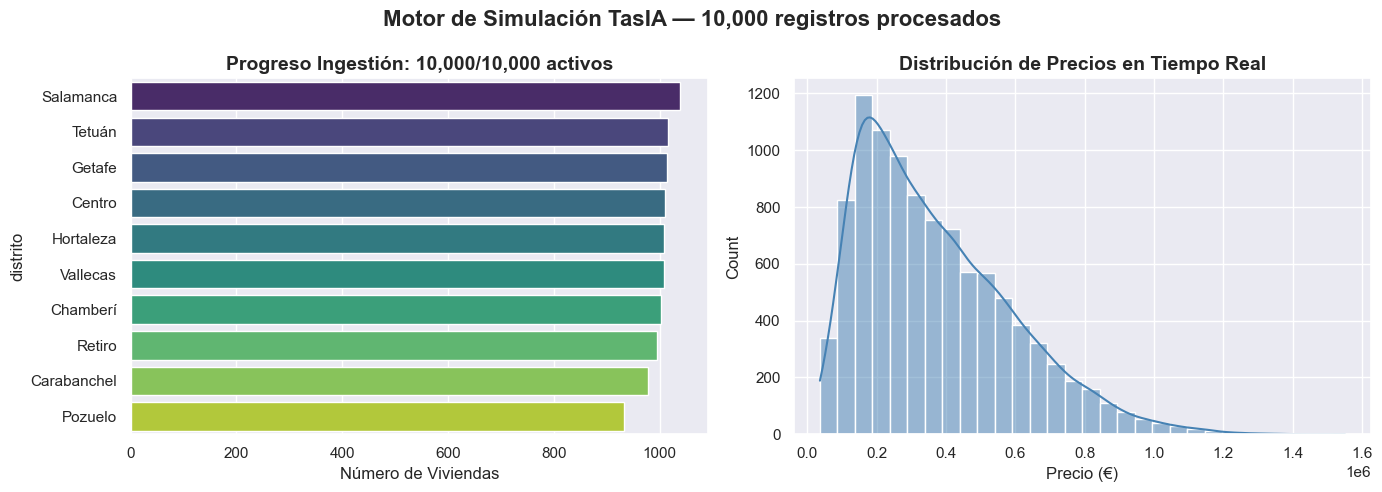

Simulación completada. 10,000 activos generados y almacenados.


In [14]:
# ==============================================================================
# 3. MOTOR DE INGESTIÓN CON DASHBOARD EN TIEMPO REAL
# ==============================================================================

def generar_datos_con_dashboard():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    # Mapeo de distritos a barrios (coherente con la App TasIA)
    MAPEO_GEOGRAFICO = {
        'Salamanca': ['Recoletos', 'Goya', 'Castellana', 'Lista', 'Guindalera'],
        'Chamberí': ['Almagro', 'Trafalgar', 'Ríos Rosas', 'Gaztambide'],
        'Centro': ['Sol', 'Malasaña', 'Chueca', 'La Latina', 'Lavapiés'],
        'Retiro': ['Ibiza', 'Jerónimos', 'Niño Jesús', 'Pacífico', 'Estrella'],
        'Tetuán': ['Cuatro Caminos', 'Bellas Vistas', 'Castillejos', 'Cuzco'],
        'Hortaleza': ['Sanchinarro', 'Conde Orgaz', 'Canillas', 'Valdefuentes'],
        'Carabanchel': ['Vista Alegre', 'Opañel', 'San Isidro', 'Comillas'],
        'Vallecas': ['Ensanche de Vallecas', 'Palomeras', 'Entrevías', 'Portazgo'],
        'Pozuelo': ['Somosaguas', 'Avenida de Europa', 'Pozuelo Centro'],
        'Getafe': ['Getafe Centro', 'El Bercial', 'Sector III', 'Getafe Norte']
    }

    # Estados de conservación realistas y variados
    ESTADOS = ['A reformar', 'Buen estado', 'Reformado', 'Lujo / Obra Nueva']
    PESOS_ESTADO = [0.15, 0.50, 0.25, 0.10]

    # Configuración de mercado realista (Madrid)
    config_mercado = {
        'Salamanca': {'precio_m2': 6500, 'ascensor_prob': 0.9},
        'Chamberí': {'precio_m2': 5800, 'ascensor_prob': 0.85},
        'Centro': {'precio_m2': 5200, 'ascensor_prob': 0.6},
        'Retiro': {'precio_m2': 6000, 'ascensor_prob': 0.9},
        'Tetuán': {'precio_m2': 3800, 'ascensor_prob': 0.5},
        'Hortaleza': {'precio_m2': 3300, 'ascensor_prob': 0.7},
        'Carabanchel': {'precio_m2': 2300, 'ascensor_prob': 0.4},
        'Vallecas': {'precio_m2': 1900, 'ascensor_prob': 0.3},
        'Pozuelo': {'precio_m2': 4500, 'ascensor_prob': 0.95},
        'Getafe': {'precio_m2': 1800, 'ascensor_prob': 0.6}
    }

    fotos_demo = [
        "https://images.unsplash.com/photo-1512917774080-9991f1c4c750?w=400",
        "https://images.unsplash.com/photo-1600596542815-27b88e54e46f?w=400",
        "https://images.unsplash.com/photo-1600607687939-ce8a6c25118c?w=400",
        "https://images.unsplash.com/photo-1600566753086-00f18fb6b3ea?w=400",
        "https://images.unsplash.com/photo-1600585154340-be6161a56a0c?w=400",
    ]

    registros_buffer = []
    total_objetivo = 10000

    print(f"Iniciando Simulación de Mercado... Objetivo: {total_objetivo:,} activos.")

    for i in range(1, total_objetivo + 1):
        # 1. Selección de distrito
        distrito, info = random.choice(list(config_mercado.items()))

        # 2. Selección de barrio (coherente con el distrito)
        barrio = random.choice(MAPEO_GEOGRAFICO[distrito])

        # 3. Características físicas
        metros = int(np.random.normal(90, 35))
        if metros < 25: metros = 25

        habs = max(1, int(metros / 25))
        banos = max(1, int(habs / 2))

        # 4. Precio con ruido de mercado
        precio_base = metros * info['precio_m2']
        precio = int(precio_base * random.uniform(0.8, 1.2))

        # 5. Características booleanas y conservación
        ascensor = 1 if random.random() < info['ascensor_prob'] else 0
        terraza = 1 if random.random() < 0.4 else 0
        estado = random.choices(ESTADOS, weights=PESOS_ESTADO, k=1)[0]
        fotos = ",".join(random.choices(fotos_demo, k=3))

        fecha_actual = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        # 6. Tupla de 15 elementos exactos para la tabla SQL
        dato = (
            f"REF_{i:05d}", f"Piso en {barrio}", precio, barrio, distrito,
            metros, habs, banos, "Planta Media", ascensor, terraza,
            estado, "E", fotos, fecha_actual
        )
        registros_buffer.append(dato)

        # 7. Escritura en BD cada 2000 registros (eficiencia)
        if i % 2000 == 0 or i == total_objetivo:
            cursor.executemany('INSERT OR REPLACE INTO viviendas VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)', registros_buffer)
            conn.commit()
            registros_buffer = []

            df_monitor = pd.read_sql("SELECT distrito, precio FROM viviendas", conn)
            clear_output(wait=True)

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            sns.countplot(y='distrito', data=df_monitor, palette='viridis',
                          order=df_monitor['distrito'].value_counts().index, ax=ax1)
            ax1.set_title(f'Progreso Ingestión: {i:,}/{total_objetivo:,} activos', fontsize=14, fontweight='bold')
            ax1.set_xlabel('Número de Viviendas')

            sns.histplot(df_monitor['precio'], bins=30, kde=True, ax=ax2, color='steelblue')
            ax2.set_title('Distribución de Precios en Tiempo Real', fontsize=14, fontweight='bold')
            ax2.set_xlabel('Precio (€)')

            fig.suptitle(f'Motor de Simulación TasIA — {i:,} registros procesados', fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()

    conn.close()
    print(f"Simulación completada. {total_objetivo:,} activos generados y almacenados.")

generar_datos_con_dashboard()

### 4. Auditoría Visual: Ficha de Producto

Como paso final de validación, muestro una **galería visual** de una muestra aleatoria de los datos capturados. Esto me permite verificar que el campo `urls_fotos` se ha poblado correctamente y que los datos tienen coherencia visual (precio vs calidad percibida).

In [15]:
# ==============================================================================
# 4. AUDITORÍA VISUAL (GALERÍA DE PRODUCTO)
# ==============================================================================

def mostrar_galeria_final():
    conn = sqlite3.connect(DB_NAME)
    # Sacamos 3 casas aleatorias de la base de datos real
    df_sample = pd.read_sql("SELECT * FROM viviendas ORDER BY RANDOM() LIMIT 3", conn)
    conn.close()

    html_content = """
    <style>
        .ficha-container { display: flex; gap: 20px; justify-content: center; font-family: 'Arial', sans-serif; }
        .ficha { border: 1px solid #e0e0e0; border-radius: 12px; width: 300px; box-shadow: 0 4px 12px rgba(0,0,0,0.1); overflow: hidden; background: white; }
        .ficha-img { width: 100%; height: 180px; object-fit: cover; }
        .ficha-body { padding: 15px; }
        .ficha-price { font-size: 22px; color: #2c3e50; font-weight: 800; margin-bottom: 5px; }
        .ficha-title { font-size: 16px; color: #7f8c8d; margin-bottom: 10px; font-weight: 500; }
        .ficha-features { display: flex; gap: 10px; font-size: 13px; color: #555; margin-bottom: 10px; }
        .badge { background-color: #d1f2eb; color: #117864; padding: 4px 8px; border-radius: 4px; font-size: 11px; font-weight: bold; }
        .badge-no { background-color: #fadbd8; color: #922b21; padding: 4px 8px; border-radius: 4px; font-size: 11px; font-weight: bold; }
    </style>
    <div class="ficha-container">
    """

    for _, row in df_sample.iterrows():
        # Cogemos la primera foto del string
        primera_foto = row['urls_fotos'].split(',')[0]
        asc_badge = '<span class="badge">Ascensor: SÍ</span>' if row['tiene_ascensor'] == 1 else '<span class="badge-no">Ascensor: NO</span>'

        html_content += f"""
        <div class="ficha">
            <img src="{primera_foto}" class="ficha-img">
            <div class="ficha-body">
                <div class="ficha-price">{row['precio']:,.0f} €</div>
                <div class="ficha-title">{row['titulo']}</div>
                <div class="ficha-features">
                    <span>📐 {row['superficie']} m²</span>
                    <span>🛏️ {row['habitaciones']} habs</span>
                    <span>🛁 {row['banos']} baños</span>
                </div>
                <div>{asc_badge}</div>
            </div>
        </div>
        """

    html_content += "</div>"
    display(HTML(html_content))

mostrar_galeria_final()

In [16]:
import sqlite3
import pandas as pd

# Conectamos a tu base de datos subida
db_path = 'tasia_db_def1.db'
conn = sqlite3.connect(db_path)

# 1. Verificar Tablas
print("--- TABLAS EN LA DB ---")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

# 2. Verificar Columnas (Schema)
print("\n--- COLUMNAS DE LA TABLA 'viviendas' ---")
try:
    columns_info = pd.read_sql("PRAGMA table_info(viviendas);", conn)
    # Mostramos nombres y tipos para asegurar que 'banos' está ahí
    print(columns_info[['cid', 'name', 'type']])
except Exception as e:
    print(f"Error leyendo tabla: {e}")

# 3. Verificar Volumen de Datos
print("\n--- CONTEO DE FILAS ---")
try:
    count = pd.read_sql("SELECT count(*) as total FROM viviendas;", conn)
    print(f"Total de viviendas: {count['total'][0]}")
except:
    print("No se pudo contar (¿tabla vacía?)")

# 4. Muestra de datos (Verificamos urls_fotos y banos)
print("\n--- MUESTRA DE DATOS (1 FILA) ---")
try:
    sample = pd.read_sql("SELECT titulo, precio, banos, urls_fotos FROM viviendas LIMIT 1;", conn)
    print(sample.to_string())
except:
    print("No se pudieron leer datos.")

conn.close()

--- TABLAS EN LA DB ---
        name
0  viviendas

--- COLUMNAS DE LA TABLA 'viviendas' ---
    cid                    name      type
0     0           id_referencia      TEXT
1     1                  titulo      TEXT
2     2                  precio      REAL
3     3                  barrio      TEXT
4     4                distrito      TEXT
5     5              superficie      REAL
6     6            habitaciones   INTEGER
7     7                   banos   INTEGER
8     8                  planta      TEXT
9     9          tiene_ascensor   INTEGER
10   10           tiene_terraza   INTEGER
11   11                  estado      TEXT
12   12  certificado_energetico      TEXT
13   13              urls_fotos      TEXT
14   14           fecha_captura  DATETIME

--- CONTEO DE FILAS ---
Total de viviendas: 10000

--- MUESTRA DE DATOS (1 FILA) ---
         titulo    precio  banos                                                                                                                      